In [1]:
import numpy as np
import sounddevice as sd
import threading
from ipywidgets import FloatSlider, ToggleButton, VBox, HBox, Label, Layout, Dropdown, HTML
from IPython.display import display, Audio
import matplotlib.pyplot as plt

from pathlib import Path 
import os
import torch

In [2]:
import RTLatentSynth

/home/lonce/miniconda3/envs/basicaudio/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
from transformers import EncodecModel
# Local imports from your project structure
from model.gru_audio_model import RNN, GRUModelConfig

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
device

'cpu'

In [5]:
run_directory = str(Path('./output/20250828_173834_encodectest_DSWind')) # 'Path to the directory of the saved run.'
config_path = os.path.join(run_directory, "config.pt")
checkpoint_path = os.path.join(run_directory, "checkpoints", "checkpoint_100.pt") #   # "last_checkpoint.pt") # "checkpoint_40.pt") # 

saved_configs = torch.load(config_path, weights_only=False)
model_config = saved_configs["model_config"]

clamp_val = saved_configs["data_config"].clamp_val # need this to map between encodec latents and model input ranges

model = RNN(model_config).to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

#-----------------------------------------------------------------------------------------------------
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz").to(device)
enc_model.eval()

warmup_len = 75
sd=.33 # to create data in [-1,1]
warmup_sequence = warmup_tensor = torch.clamp(torch.randn(warmup_len, 128) * sd, -3*sd, 3*sd)    

In [6]:
itest=RTLatentSynth.InteractiveSynthTest( model, enc_model, clamp_val)
iaudio=itest.simulate_real_time(duration_seconds=1, param_change_interval=0.5)

Synthesizer initialized:
  Buffer size: 24000 samples (1000.0ms)
  Latent window: 75 frames (1000.0ms)
  Samples per frame: 320
Initializing with 75 warmup frames (= latent_window_size)...
Warmup complete. Ready to generate new frames.
Simulating 1s of real-time synthesis...
Updated conditioning: {'param0': tensor(0.)}

Performance Stats:
  buffer_length_ms: 1000.00
  latent_buffer_size: 75.00
  current_position_seconds: 1.00
  frames_generated_post_warmup: 77.00
  generation_calls: 77.00
  avg_generation_time_ms: 0.97
  max_generation_time_ms: 1.46


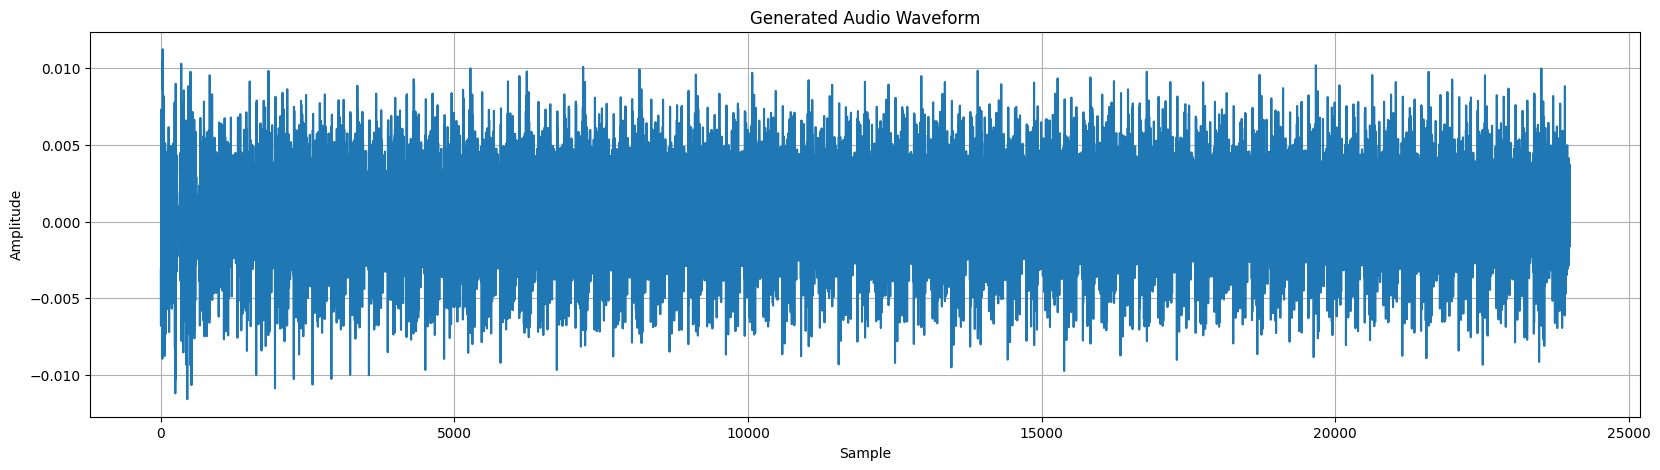

In [7]:
plt.figure(figsize=(20, 5))
plt.plot(iaudio)
plt.title("Generated Audio Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()
#plt.savefig(args.output_plot_path)
#plt.close()

plt.show()

In [8]:
Audio(iaudio, rate=24000)
